In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

In [2]:
# New One
def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    return value


def weighted_cness(G, W):
    edges = list(G.edges())
    w_closeness = []
    for i in range(0, len(edges)):
        closeness = []
        nd_1 = edges[i][0]
        nd_2 = edges[i][1]
        weight_1 = weight_of_a_node(G,nd_1,W)
        weight_2 = weight_of_a_node(G,nd_2,W)
        edge_w = G.get_edge_data(nd_1, nd_2)
        val = edge_w['weight']
        influence_edge_val = (weight_1 + weight_2) * (val/W)
        closeness.append(edges[i])
        closeness.append(influence_edge_val)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_

def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### s_s_1

Name: 
Type: Graph
Number of nodes: 10
Number of edges: 11
Average degree:   2.2000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


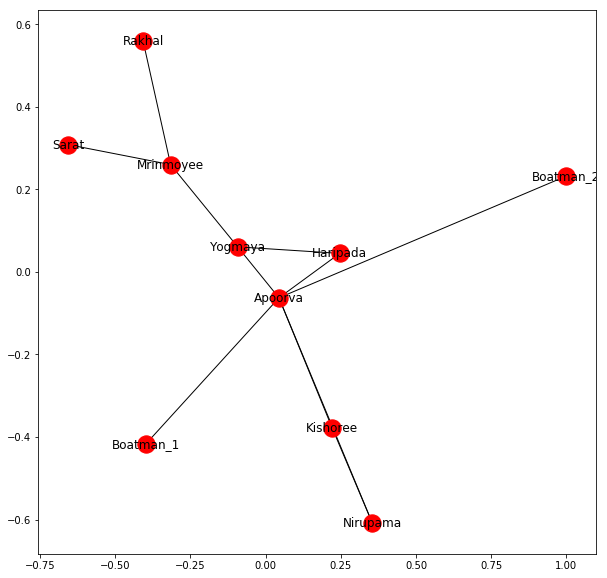

[[('Apoorva', 'Boatman_1'), 0.027557297832288614], [('Apoorva', 'Boatman_2'), 0.006889324458072154], [('Apoorva', 'Yogmaya'), 0.8799705020473908], [('Apoorva', 'Haripada'), 0.20382697122008964], [('Apoorva', 'Nirupama'), 0.01420559296706709], [('Apoorva', 'Kishoree'), 0.08523355780240253], [('Yogmaya', 'Haripada'), 0.007859651846533021], [('Yogmaya', 'Mrinmoyee'), 0.24720060548429038], [('Nirupama', 'Kishoree'), 0.0708727124531817], [('Mrinmoyee', 'Sarat'), 0.05356207184303985], [('Mrinmoyee', 'Rakhal'), 0.06695258980379981]]


In [3]:
sm_1 = nx.read_weighted_edgelist('s_m_1.txt', delimiter=',')
print(nx.info(sm_1))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_1)
plt.show()

total_edge_weight = total_weight_of_G(sm_1) #NCF
w_ncf_1 = weighted_cness(sm_1,total_edge_weight)
print(w_ncf_1)

In [4]:
edge_w = list(w_ncf_1)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                   Edges        IF
0   (Apoorva, Boatman_1)  0.027557
1   (Apoorva, Boatman_2)  0.006889
2     (Apoorva, Yogmaya)  0.879971
3    (Apoorva, Haripada)  0.203827
4    (Apoorva, Nirupama)  0.014206
5    (Apoorva, Kishoree)  0.085234
6    (Yogmaya, Haripada)  0.007860
7   (Yogmaya, Mrinmoyee)  0.247201
8   (Nirupama, Kishoree)  0.070873
9     (Mrinmoyee, Sarat)  0.053562
10   (Mrinmoyee, Rakhal)  0.066953
          IF
0   0.029085
1   0.007271
2   0.928752
3   0.215126
4   0.014993
5   0.089959
6   0.008295
7   0.260904
8   0.074802
9   0.056531
10  0.070664


### s_s_2

Name: 
Type: Graph
Number of nodes: 11
Number of edges: 13
Average degree:   2.3636


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


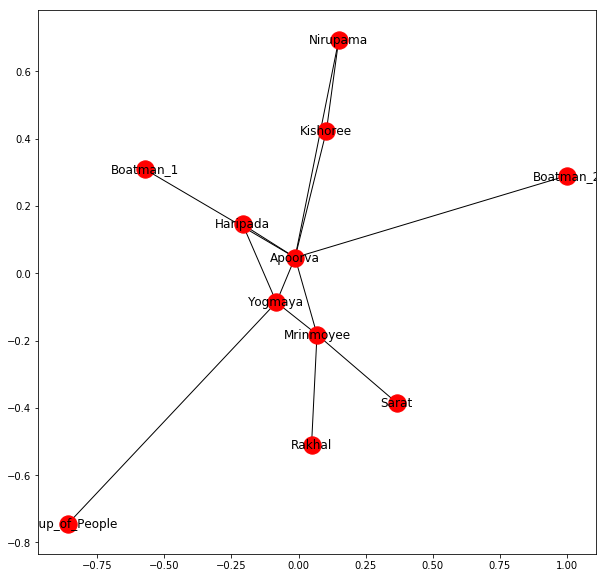

[[('Apoorva', 'Boatman_1'), 0.023332282329624792], [('Apoorva', 'Boatman_2'), 0.005833070582406198], [('Apoorva', 'Yogmaya'), 0.7378046033962434], [('Apoorva', 'Haripada'), 0.16965452006666365], [('Apoorva', 'Nirupama'), 0.011913877753254358], [('Apoorva', 'Kishoree'), 0.07148326651952615], [('Apoorva', 'Mrinmoyee'), 0.40842754830863476], [('Yogmaya', 'Haripada'), 0.018478897346966353], [('Yogmaya', 'Mrinmoyee'), 0.23269222107112295], [('Yogmaya', 'Group_of_People'), 0.0049434710148191525], [('Nirupama', 'Kishoree'), 0.05722715193009325], [('Mrinmoyee', 'Sarat'), 0.05567316787532093], [('Mrinmoyee', 'Rakhal'), 0.06959145984415116]]


In [5]:
sm_2 = nx.read_weighted_edgelist('s_m_2.txt', delimiter=',')
print(nx.info(sm_2))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_2)
plt.show()

total_edge_weight = total_weight_of_G(sm_2) #NCF
w_ncf_2 = weighted_cness(sm_2,total_edge_weight)
print(w_ncf_2)

In [6]:
edge_w = list(w_ncf_2)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0         (Apoorva, Boatman_1)  0.023332
1         (Apoorva, Boatman_2)  0.005833
2           (Apoorva, Yogmaya)  0.737805
3          (Apoorva, Haripada)  0.169655
4          (Apoorva, Nirupama)  0.011914
5          (Apoorva, Kishoree)  0.071483
6         (Apoorva, Mrinmoyee)  0.408428
7          (Yogmaya, Haripada)  0.018479
8         (Yogmaya, Mrinmoyee)  0.232692
9   (Yogmaya, Group_of_People)  0.004943
10        (Nirupama, Kishoree)  0.057227
11          (Mrinmoyee, Sarat)  0.055673
12         (Mrinmoyee, Rakhal)  0.069591
          IF
0   0.025901
1   0.006475
2   0.819020
3   0.188329
4   0.013225
5   0.079352
6   0.453386
7   0.020513
8   0.258306
9   0.005488
10  0.063527
11  0.061801
12  0.077252


### s_s_3

Name: 
Type: Graph
Number of nodes: 11
Number of edges: 13
Average degree:   2.3636


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


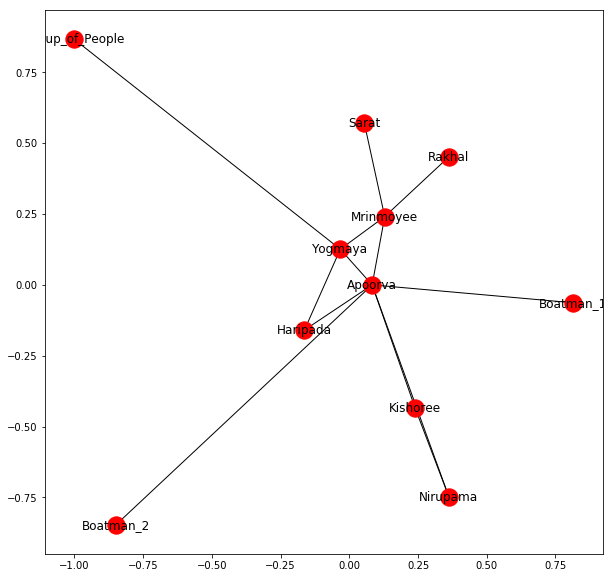

[[('Apoorva', 'Boatman_1'), 0.019382959553899726], [('Apoorva', 'Boatman_2'), 0.004845739888474932], [('Apoorva', 'Yogmaya'), 0.6281767193448105], [('Apoorva', 'Haripada'), 0.13960113960113962], [('Apoorva', 'Nirupama'), 0.009870049756089643], [('Apoorva', 'Kishoree'), 0.05922029853653786], [('Apoorva', 'Mrinmoyee'), 0.4935674223423511], [('Yogmaya', 'Haripada'), 0.015243382764750287], [('Yogmaya', 'Mrinmoyee'), 0.19869968587917305], [('Yogmaya', 'Group_of_People'), 0.003993474078944164], [('Nirupama', 'Kishoree'), 0.04589248463892339], [('Mrinmoyee', 'Sarat'), 0.10931729450247968], [('Mrinmoyee', 'Rakhal'), 0.11772631715651659]]


In [7]:
sm_3 = nx.read_weighted_edgelist('s_m_3.txt', delimiter=',')
print(nx.info(sm_3))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_3)
plt.show()

total_edge_weight = total_weight_of_G(sm_3) #NCF
w_ncf_3 = weighted_cness(sm_3,total_edge_weight)
print(w_ncf_3)

In [8]:
edge_w = list(w_ncf_3)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["IF"] = np.concatenate(normalized_if).ravel()

print(df_2)

                         Edges        IF
0         (Apoorva, Boatman_1)  0.019383
1         (Apoorva, Boatman_2)  0.004846
2           (Apoorva, Yogmaya)  0.628177
3          (Apoorva, Haripada)  0.139601
4          (Apoorva, Nirupama)  0.009870
5          (Apoorva, Kishoree)  0.059220
6         (Apoorva, Mrinmoyee)  0.493567
7          (Yogmaya, Haripada)  0.015243
8         (Yogmaya, Mrinmoyee)  0.198700
9   (Yogmaya, Group_of_People)  0.003993
10        (Nirupama, Kishoree)  0.045892
11          (Mrinmoyee, Sarat)  0.109317
12         (Mrinmoyee, Rakhal)  0.117726
          IF
0   0.022696
1   0.005674
2   0.735551
3   0.163463
4   0.011557
5   0.069343
6   0.577933
7   0.017849
8   0.232664
9   0.004676
10  0.053737
11  0.128003
12  0.137849


### s_s_4

Name: 
Type: Graph
Number of nodes: 12
Number of edges: 16
Average degree:   2.6667


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


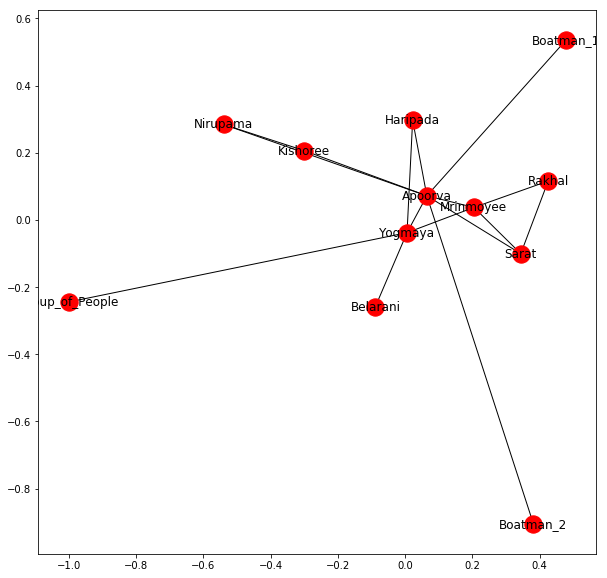

[[('Apoorva', 'Boatman_1'), 0.014643258783837832], [('Apoorva', 'Boatman_2'), 0.003660814695959458], [('Apoorva', 'Yogmaya'), 0.6851087657219758], [('Apoorva', 'Haripada'), 0.10786228184508825], [('Apoorva', 'Nirupama'), 0.007425148573552732], [('Apoorva', 'Kishoree'), 0.04455089144131639], [('Apoorva', 'Mrinmoyee'), 0.43723679071715266], [('Apoorva', 'Sarat'), 0.03709751036368171], [('Yogmaya', 'Haripada'), 0.011815302958295887], [('Yogmaya', 'Mrinmoyee'), 0.15228612701803587], [('Yogmaya', 'Group_of_People'), 0.003199683795954282], [('Yogmaya', 'Belarani'), 0.09919019767458274], [('Nirupama', 'Kishoree'), 0.033954291575891325], [('Mrinmoyee', 'Sarat'), 0.10582483613384089], [('Mrinmoyee', 'Rakhal'), 0.10853045110836104], [('Sarat', 'Rakhal'), 0.002936180424522753]]


In [9]:
sm_4 = nx.read_weighted_edgelist('s_m_4.txt', delimiter=',')
print(nx.info(sm_4))

plt.figure(figsize = (10,10))
nx.draw_networkx(sm_4)
plt.show()

total_edge_weight = total_weight_of_G(sm_4) #NCF
w_ncf_4 = weighted_cness(sm_4,total_edge_weight)
print(w_ncf_4)

In [10]:
edge_w = list(w_ncf_4)

df = pd.DataFrame()
df["Edges"] = convert_to_list_value(edge_w,0)
df["IF"] = convert_to_list_value(edge_w,1)\

print(df)

if_df = np.array(df['IF'])
normalized_if = preprocessing.normalize([if_df])
df_2 = pd.DataFrame()
df_2["Edges"] = convert_to_list_value(edge_w,0)
df_2["IF"] = np.concatenate(normalized_if).ravel()
df_2.to_csv('s_r_t4.csv')
print(df_2)

                         Edges        IF
0         (Apoorva, Boatman_1)  0.014643
1         (Apoorva, Boatman_2)  0.003661
2           (Apoorva, Yogmaya)  0.685109
3          (Apoorva, Haripada)  0.107862
4          (Apoorva, Nirupama)  0.007425
5          (Apoorva, Kishoree)  0.044551
6         (Apoorva, Mrinmoyee)  0.437237
7             (Apoorva, Sarat)  0.037098
8          (Yogmaya, Haripada)  0.011815
9         (Yogmaya, Mrinmoyee)  0.152286
10  (Yogmaya, Group_of_People)  0.003200
11         (Yogmaya, Belarani)  0.099190
12        (Nirupama, Kishoree)  0.033954
13          (Mrinmoyee, Sarat)  0.105825
14         (Mrinmoyee, Rakhal)  0.108530
15             (Sarat, Rakhal)  0.002936
                         Edges        IF
0         (Apoorva, Boatman_1)  0.017102
1         (Apoorva, Boatman_2)  0.004275
2           (Apoorva, Yogmaya)  0.800136
3          (Apoorva, Haripada)  0.125972
4          (Apoorva, Nirupama)  0.008672
5          (Apoorva, Kishoree)  0.052031
6         (Apoor